# Abandono escolar no ensino médio

Análise exploratória das Taxas de Rendimento Escolar publicadas pelo Inep para 2019 a 2025.

O objetivo é entender evolução, diferenças territoriais e recortes de localização. Os dados são agregados e não permitem afirmar causas individuais.

## 1. Preparação

O CSV processado preserva Brasil, regiões, UFs, localização e dependência administrativa. As funções do projeto validam o esquema antes da análise.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

BASE_DIR = Path.cwd()
if not (BASE_DIR / "src").exists():
    BASE_DIR = BASE_DIR.parent
sys.path.insert(0, str(BASE_DIR))

from src.analysis import comparar_anos_ufs, lacuna_rural_urbana_ufs, ranking_ufs, serie_unidade
from src.data import carregar_dados, resumo_qualidade

ARQUIVO = BASE_DIR / "data" / "taxas_rendimento_ensino_medio_2019_2025.csv"
dados = carregar_dados(ARQUIVO)
dados.shape

(4105, 8)

In [2]:
qualidade = pd.Series(resumo_qualidade(dados), name="valor")
qualidade

linhas                   4105.000000
linhas_completas         3783.000000
cobertura_pct              92.155907
celulas_ausentes          966.000000
linhas_inconsistentes       0.000000
duplicidades                0.000000
Name: valor, dtype: float64

A cobertura considera linhas com aprovação, reprovação e abandono disponíveis. Valores ausentes não foram preenchidos.

## 2. Evolução nacional

In [3]:
brasil = serie_unidade(dados, "Brasil")
brasil[["ano", "taxa_aprovacao", "taxa_reprovacao", "taxa_abandono"]]

,ano,taxa_aprovacao,taxa_reprovacao,taxa_abandono
0,2019,86.1,9.1,4.8
1,2020,95.0,2.7,2.3
2,2021,90.8,4.2,5.0
3,2022,86.6,7.7,5.7
4,2023,91.3,5.3,3.4
5,2024,91.7,5.1,3.2
6,2025,94.8,3.0,2.2


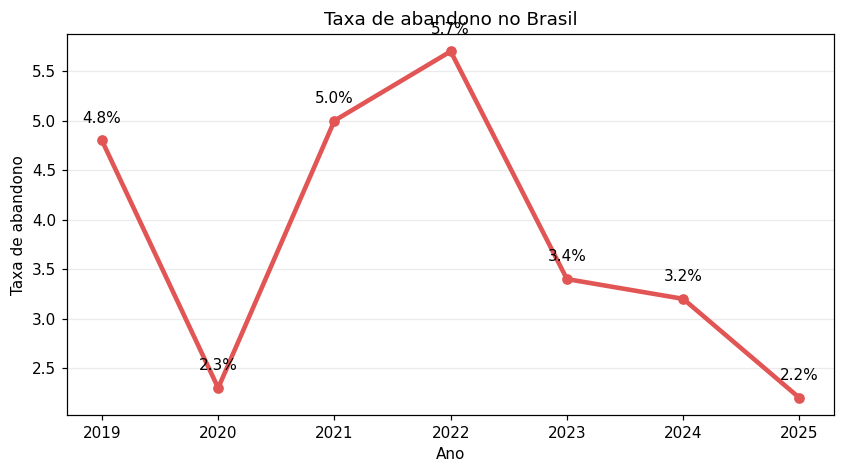

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(brasil["ano"], brasil["taxa_abandono"], marker="o", linewidth=3, color="#E25555")
for _, linha in brasil.iterrows():
    ax.text(linha["ano"], linha["taxa_abandono"] + 0.18, f"{linha['taxa_abandono']:.1f}%", ha="center")
ax.set(title="Taxa de abandono no Brasil", xlabel="Ano", ylabel="Taxa de abandono")
ax.set_xticks(brasil["ano"])
ax.grid(axis="y", alpha=0.25)
plt.show()

A série saiu de 4,8% em 2019, atingiu 5,7% em 2022 e chegou a 2,2% em 2025. Os anos de pandemia precisam de interpretação contextual.

## 3. Distribuição entre as UFs em 2025

In [5]:
ranking_2025 = ranking_ufs(dados, 2025)
ranking_2025[["posicao", "unidade_geografica", "regiao", "taxa_abandono", "diferenca_brasil_pp"]].head(10)

,posicao,unidade_geografica,regiao,taxa_abandono,diferenca_brasil_pp
0,1,Amapá,Norte,4.4,2.2
1,2,Acre,Norte,4.3,2.1
2,3,Rondônia,Norte,4.0,1.8
3,4,Roraima,Norte,4.0,1.8
4,5,Amazonas,Norte,3.9,1.7
5,6,Paraíba,Nordeste,3.4,1.2
6,7,Santa Catarina,Sul,3.3,1.1
7,8,Rio de Janeiro,Sudeste,3.1,0.9
8,9,Distrito Federal,Centro-Oeste,3.0,0.8
9,10,Maranhão,Nordeste,3.0,0.8


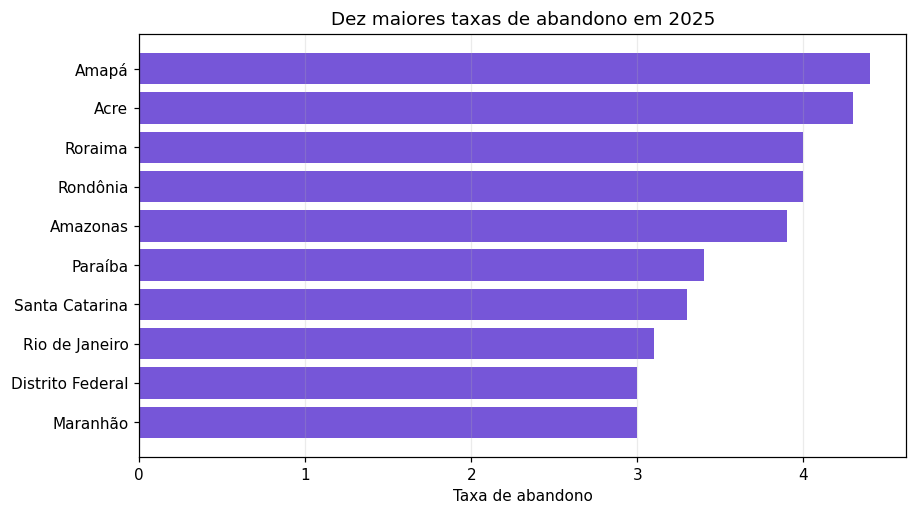

In [6]:
top_10 = ranking_2025.head(10).sort_values("taxa_abandono")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_10["unidade_geografica"], top_10["taxa_abandono"], color="#7656D8")
ax.set(title="Dez maiores taxas de abandono em 2025", xlabel="Taxa de abandono")
ax.grid(axis="x", alpha=0.25)
plt.show()

## 4. Mudança entre 2019 e 2025

In [7]:
comparacao = comparar_anos_ufs(dados, 2025, 2019)
comparacao[[
    "unidade_geografica",
    "taxa_abandono_base",
    "taxa_abandono_atual",
    "variacao_pp",
    "situacao",
]].sort_values("variacao_pp").head(10)

,unidade_geografica,taxa_abandono_base,taxa_abandono_atual,variacao_pp,situacao
26,Mato Grosso,9.6,0.1,-9.5,Até o Brasil e melhorou
22,Pará,10.1,0.6,-9.5,Até o Brasil e melhorou
24,Piauí,7.2,0.4,-6.8,Até o Brasil e melhorou
4,Amazonas,10.2,3.9,-6.3,"Acima do Brasil, mas melhorou"
0,Amapá,9.7,4.4,-5.3,"Acima do Brasil, mas melhorou"
20,Mato Grosso do Sul,6.0,0.8,-5.2,Até o Brasil e melhorou
12,Rio Grande do Norte,7.5,2.7,-4.8,"Acima do Brasil, mas melhorou"
17,Alagoas,6.1,1.3,-4.8,Até o Brasil e melhorou
15,Sergipe,6.3,1.6,-4.7,Até o Brasil e melhorou
11,Bahia,7.1,2.7,-4.4,"Acima do Brasil, mas melhorou"


In [8]:
comparacao["situacao"].value_counts().rename("quantidade")

situacao
Acima do Brasil, mas melhorou    14
Até o Brasil e melhorou          12
Acima do Brasil e piorou          1
Name: quantidade, dtype: int64

## 5. Diferença rural e urbana

In [9]:
lacunas = lacuna_rural_urbana_ufs(dados, 2025)
lacunas[["unidade_geografica", "regiao", "Rural", "Urbana", "diferenca_rural_urbana_pp"]].head(10)

localizacao,unidade_geografica,regiao,Rural,Urbana,diferenca_rural_urbana_pp
0,Acre,Norte,9.1,2.7,6.4
22,Roraima,Norte,7.4,2.9,4.5
3,Amazonas,Norte,6.4,3.3,3.1
9,Maranhão,Nordeste,4.8,2.6,2.2
2,Amapá,Norte,5.8,4.3,1.5
26,Tocantins,Norte,1.6,1.0,0.6
16,Pernambuco,Nordeste,1.1,0.6,0.5
7,Espírito Santo,Sudeste,1.0,0.5,0.5
8,Goiás,Centro-Oeste,1.3,0.8,0.5
6,Distrito Federal,Centro-Oeste,3.5,3.0,0.5


## Conclusões

1. A taxa nacional de abandono foi de 2,2% em 2025, redução de 1,0 ponto percentual em relação a 2024.
2. Amapá apresentou a maior taxa entre as UFs em 2025, 4,4%.
3. A distância entre a maior e a menor taxa estadual foi de 4,3 pontos percentuais.
4. O Acre apresentou a maior diferença entre área rural e urbana em 2025, 6,4 pontos percentuais.
5. Os resultados indicam onde aprofundar o diagnóstico, mas não explicam por que o abandono ocorreu.